# Preliminary Data Exploration

## Data Cleanup

Data is not terrible; although a few columns that should be numbers are strings.
EW_CAPABILITY and Intel Confidence also have a few NA's.

### Explore data cleanliness

In [1]:
import pandas as pd


def load_predictive_warfighting_data(file_path: str = "unh_hackathon_prompt_2_data.json") -> pd.DataFrame:
    """Load data from a CSV file into a pandas DataFrame."""
    return pd.read_json(file_path)

dirty_df = load_predictive_warfighting_data()

# print data types of each column
print(dirty_df.dtypes)

Threat Type                         str
enemy_unit_count                  int64
Enemy.Capability.Index            int64
ThreatEscalationHours             int64
friendlyUnitCount                 int64
LCS_COUNT                         int64
Aircraft Count                    int64
cyber_defense_teams               int64
Patriot.Batteries                 int64
ISR_AssetCount                    int64
satellite coverage score        float64
JointForceIntegration             int64
EW_Capability                       str
Supply Chain Resilience         float64
PriorEngagements                  int64
force_readiness_score             int64
Intel Confidence                    str
ResponseTime_hrs                  int64
logistics_delay_hours             int64
CMD_COORD_SCORE                   int64
roe_complexity_score              int64
Operational Budget (MUSD)         int64
BudgetUtilization_pct             int64
Weather_Severity                  int64
Theater Distance KM             float64


### Clean the data

In [2]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the DataFrame by converting data types."""

    # Convert the string "NULL" to pd.NA
    df = df.replace("NULL", pd.NA)
    df = df.replace("N/A", pd.NA)

    for numeric_string_column in [
        "Enemy.Capability.Index",
        "EW_Capability",
        "Intel Confidence",

    ]:
        df[numeric_string_column] = pd.to_numeric(df[numeric_string_column])

    for boolean_string_column in [
        "response_success"
    ]:
        df[boolean_string_column] = df[boolean_string_column].map({"Yes": 1, "No": 0, "1": 1, "0": 0})

    df['Threat Type'] = df['Threat Type'].str.replace(" ", "")
    df['Threat Type'] = df['Threat Type'].str.lower()
    df["Season"] = df["Season"].str.replace(" ", "")
    df["Season"] = df["Season"].str.lower()
    df = df.replace("msl", "missile")
    df = df.replace("autumn", "fall")

    return df

df = clean_data(dirty_df)
df.head()

,Threat Type,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,...,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,Season,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
0,missile,25,8,34,21,0,0,0,4,12,...,7,3,98,84,3,5164.8,winter,1,388,10.1
1,missile,3,2,8,45,0,0,0,4,4,...,9,5,189,97,1,7149.7,fall,1,244,2.0
2,air,7,3,48,45,0,5,0,0,14,...,9,1,92,88,0,6706.5,winter,1,280,2.0
3,cyber,31,7,70,57,0,0,7,0,5,...,10,3,314,86,9,1851.9,fall,1,330,5.3
4,hybrid,14,5,27,57,0,0,0,0,10,...,6,4,290,84,4,983.7,spring,1,240,11.0


In [3]:
for column in df.columns:
    if df.dtypes[column] == "str":
        print(f"Values: {df[column].drop_duplicates()}")
    else: 
        print(f"Name: {column}, dtype: {df.dtypes[column]}, min: {df[column].min()}, max: {df[column].max()}")

Values: 0    missile
2        air
3      cyber
4     hybrid
7      naval
Name: Threat Type, dtype: str
Name: enemy_unit_count, dtype: int64, min: 1, max: 50
Name: Enemy.Capability.Index, dtype: int64, min: 1, max: 10
Name: ThreatEscalationHours, dtype: int64, min: 1, max: 72
Name: friendlyUnitCount, dtype: int64, min: 5, max: 60
Name: LCS_COUNT, dtype: int64, min: 0, max: 8
Name: Aircraft Count, dtype: int64, min: 0, max: 24
Name: cyber_defense_teams, dtype: int64, min: 0, max: 12
Name: Patriot.Batteries, dtype: int64, min: 0, max: 6
Name: ISR_AssetCount, dtype: int64, min: 0, max: 15
Name: satellite coverage score, dtype: float64, min: 0.2, max: 1.0
Name: JointForceIntegration, dtype: int64, min: 1, max: 10
Name: EW_Capability, dtype: float64, min: 0.0, max: 10.0
Name: Supply Chain Resilience, dtype: float64, min: 0.4, max: 1.0
Name: PriorEngagements, dtype: int64, min: 0, max: 25
Name: force_readiness_score, dtype: int64, min: 40, max: 100
Name: Intel Confidence, dtype: float64, min:

In [4]:
OUTCOME_COLUMNS = ["response_success", "actual_days_to_stabilization", "Financial_Loss_MUSD"]

### Missing values check

EW_Capability and Intel Confidence have a few null values.

TODO LATER: explore if there are any patterns in the data for these null columns.

In [5]:
print(df.isna().sum())

Threat Type                      0
enemy_unit_count                 0
Enemy.Capability.Index           0
ThreatEscalationHours            0
friendlyUnitCount                0
LCS_COUNT                        0
Aircraft Count                   0
cyber_defense_teams              0
Patriot.Batteries                0
ISR_AssetCount                   0
satellite coverage score         0
JointForceIntegration            0
EW_Capability                   30
Supply Chain Resilience          0
PriorEngagements                 0
force_readiness_score            0
Intel Confidence                25
ResponseTime_hrs                 0
logistics_delay_hours            0
CMD_COORD_SCORE                  0
roe_complexity_score             0
Operational Budget (MUSD)        0
BudgetUtilization_pct            0
Weather_Severity                 0
Theater Distance KM              0
Season                           0
response_success                 0
Financial_Loss_MUSD              0
actual_days_to_stabi

In [6]:
# print(df.isna())
pd.set_option("display.max_columns", None)
df[df["Intel Confidence"].isnull()]

,Threat Type,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,satellite coverage score,JointForceIntegration,EW_Capability,Supply Chain Resilience,PriorEngagements,force_readiness_score,Intel Confidence,ResponseTime_hrs,logistics_delay_hours,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,Season,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
94,missile,8,5,14,11,0,0,0,4,3,0.65,4,9.0,0.55,19,54,NaN,44,11,6,3,52,74,3,6395.2,spring,1,274,6.9
159,hybrid,45,5,6,52,0,0,0,0,0,0.93,5,2.0,0.98,9,88,NaN,32,2,6,4,476,93,6,529.9,spring,1,190,7.1
205,air,33,7,53,29,0,17,0,0,12,0.90,8,8.0,0.69,11,63,NaN,28,20,10,3,443,83,2,6228.7,spring,1,481,7.9
373,naval,42,7,63,52,6,0,0,0,14,0.38,2,3.0,0.63,15,67,NaN,25,3,5,1,113,95,0,6697.9,winter,1,415,5.5
450,air,14,9,28,19,0,5,0,0,7,0.66,7,8.0,0.97,3,50,NaN,40,16,8,3,181,71,2,5961.6,winter,1,335,10.6
547,naval,31,5,30,43,3,0,0,0,5,0.38,9,6.0,0.41,12,93,NaN,42,15,2,5,422,72,6,8379.4,winter,1,344,11.0
776,missile,44,9,40,35,0,0,0,3,15,0.83,2,9.0,0.63,1,71,NaN,18,13,10,5,440,70,2,1997.9,fall,0,452,11.1
779,missile,46,7,4,30,0,0,0,1,15,0.60,10,4.0,0.71,2,57,NaN,47,17,9,4,479,97,1,1848.6,summer,1,406,4.4
795,air,43,9,68,23,0,19,0,0,8,0.72,10,0.0,0.82,11,58,NaN,17,11,4,5,100,84,9,819.4,spring,1,430,6.3
949,naval,32,3,37,39,6,0,0,0,9,0.76,2,5.0,0.68,17,92,NaN,9,11,9,3,473,88,4,3439.0,summer,1,301,5.5


In [7]:
df.groupby(["Threat Type", "Season"]).count()

enemy_unit_count  Enemy.Capability.Index  \
Threat Type Season                                             
air         fall                 173                     173   
            spring               184                     184   
            summer               180                     180   
            winter               204                     204   
cyber       fall                 119                     119   
            spring               114                     114   
            summer               113                     113   
            winter               124                     124   
hybrid      fall                 129                     129   
            spring               147                     147   
            summer               139                     139   
            winter               157                     157   
missile     fall                 123                     123   
            spring               112                     112   
            summer               109                     109   
            winter                98                      98   
naval       fall                 170                     170   
            spring               206                     206   
            summer               204                     204   
            winter               195                     195   

                    ThreatEscalationHours  friendlyUnitCount  LCS_COUNT  \
Threat Type Season                                                        
air         fall                      173                173        173   
            spring                    184                184        184   
            summer                    180                180        180   
            winter                    204                204        204   
cyber       fall                      119                119        119   
            spring                    114                114        114   
            summer                    113                113        113   
            winter                    124                124        124   
hybrid      fall                      129                129        129   
            spring                    147                147        147   
            summer                    139                139        139   
            winter                    157                157        157   
missile     fall                      123                123        123   
            spring                    112                112        112   
            summer                    109                109        109   
            winter                     98                 98         98   
naval       fall                      170                170        170   
            spring                    206                206        206   
            summer                    204                204        204   
            winter                    195                195        195   

                    Aircraft Count  cyber_defense_teams  Patriot.Batteries  \
Threat Type Season                                                           
air         fall               173                  173                173   
            spring             184                  184                184   
            summer             180                  180                180   
            winter             204                  204                204   
cyber       fall               119                  119                119   
            spring             114                  114                114   
            summer             113                  113                113   
            winter             124                  124                124   
hybrid      fall               129                  129                129   
            spring             147                  147                147   
            summer      

## Train / Test Split

Before we dive further, it's important to reserve some of the data as a test set. That way our evaluation down the road will still be unbiased even if we engineer a model's features on the basis of what we find in our analysis.

In [8]:
TRAIN_FRACTION=0.8
def split(df: pd.DataFrame, frac: float, random_state: int=42):
    train_df = df.sample(frac=frac, random_state=random_state)
    test_df = df.drop(train_df.index)
    return train_df, test_df

train_df, test_df = split(df, TRAIN_FRACTION)

## Correlation analysis

### Compute correlation of fields

In [9]:
correlation_matrix = train_df.select_dtypes(exclude=[pd.StringDtype]).corr()
correlation_matrix

/var/folders/qs/jcmgcls10w3clr880myj3y3m0000gp/T/ipykernel_31427/443309417.py:1: UserWarning: Instantiating StringDtype without any arguments.Pass a StringDtype instance to silence this warning.
  correlation_matrix = train_df.select_dtypes(exclude=[pd.StringDtype]).corr()


,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,satellite coverage score,JointForceIntegration,EW_Capability,Supply Chain Resilience,PriorEngagements,force_readiness_score,Intel Confidence,ResponseTime_hrs,logistics_delay_hours,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
enemy_unit_count,1.000000,0.030340,0.011560,0.011785,-0.004453,0.008104,0.021492,-0.007721,0.013723,-0.003528,0.038649,0.015309,-0.017962,0.009790,-0.021503,-0.008968,0.001768,0.019362,0.002887,-0.018665,0.022749,0.033747,0.003610,-0.038888,-0.103322,0.390822,0.024088
Enemy.Capability.Index,0.030340,1.000000,0.020750,0.033608,-0.018010,0.002674,-0.011624,0.029226,0.041913,0.008861,0.013066,0.014123,0.013543,0.022300,-0.030672,0.005016,-0.004662,-0.025509,0.014421,0.031363,-0.009266,-0.007993,-0.027946,0.006450,-0.391682,0.405702,0.100299
ThreatEscalationHours,0.011560,0.020750,1.000000,0.013678,0.011420,-0.027830,0.021191,-0.014160,0.014895,0.025494,-0.008629,0.003499,0.021609,0.019485,-0.006433,-0.040849,-0.032307,0.023187,0.014367,-0.006469,0.002116,-0.006228,0.033396,0.015685,-0.156243,0.062626,0.056890
friendlyUnitCount,0.011785,0.033608,0.013678,1.000000,0.018623,0.032474,0.001568,-0.033848,0.023332,-0.024906,0.008584,-0.045448,0.004282,0.012811,-0.008693,-0.000479,-0.002048,-0.025897,0.024786,0.001394,0.031364,-0.020997,0.033644,0.009566,-0.009125,0.038218,-0.036710
LCS_COUNT,-0.004453,-0.018010,0.011420,0.018623,1.000000,-0.237511,-0.178070,-0.156583,0.001421,-0.017933,0.016850,0.003849,-0.010637,-0.003906,-0.001904,-0.042210,-0.019166,-0.014973,0.012527,-0.001524,-0.010264,-0.045905,-0.003306,-0.007491,0.059739,0.159619,-0.002811
Aircraft Count,0.008104,0.002674,-0.027830,0.032474,-0.237511,1.000000,-0.184183,-0.161958,-0.002721,0.010719,-0.004028,-0.019786,0.012344,0.031613,0.020387,-0.001295,0.007265,0.025457,0.004125,-0.015177,-0.014136,0.030205,0.005311,-0.010342,0.128918,0.406336,-0.006617
cyber_defense_teams,0.021492,-0.011624,0.021191,0.001568,-0.178070,-0.184183,1.000000,-0.121425,-0.004376,-0.018432,0.003454,0.014581,0.000360,0.023369,-0.002116,-0.030648,0.020737,-0.001148,-0.006524,-0.010246,-0.006408,0.009487,0.006313,0.009857,0.053688,-0.056428,-0.297426
Patriot.Batteries,-0.007721,0.029226,-0.014160,-0.033848,-0.156583,-0.161958,-0.121425,1.000000,-0.014935,0.005270,-0.006594,0.027743,-0.004903,-0.023234,-0.012850,0.017581,0.038216,-0.007149,0.007736,0.023753,0.022594,0.002018,0.008652,0.000656,0.030549,-0.016751,-0.107021
ISR_AssetCount,0.013723,0.041913,0.014895,0.023332,0.001421,-0.002721,-0.004376,-0.014935,1.000000,-0.027374,0.025132,-0.015802,0.007751,0.000244,-0.007446,-0.006074,0.018907,0.005629,0.000202,-0.025682,0.008952,-0.015684,0.034262,-0.002378,0.082713,0.307288,-0.187827
satellite coverage score,-0.003528,0.008861,0.025494,-0.024906,-0.017933,0.010719,-0.018432,0.005270,-0.027374,1.000000,0.002054,0.027361,0.008671,0.017321,0.005884,0.038660,0.004647,-0.012169,-0.026096,-0.007501,-0.006245,-0.006042,-0.024907,0.019262,0.063970,-0.038023,-0.081514


### Most correlated fields

If two fields have very high correlation (either positive or negative), it may be a good idea to drop one of them from our analysis as they are redundant.

In [10]:
sorted_by_most_correlated = correlation_matrix.reset_index().melt(
    id_vars=['index'],
).sort_values(by="value", key=abs, ascending=False)
sorted_by_most_correlated = sorted_by_most_correlated[sorted_by_most_correlated["index"] != sorted_by_most_correlated["variable"]]
sorted_by_most_correlated.head(30)

,index,variable,value
485,actual_days_to_stabilization,logistics_delay_hours,0.644830
719,logistics_delay_hours,actual_days_to_stabilization,0.644830
726,response_success,actual_days_to_stabilization,-0.464321
674,actual_days_to_stabilization,response_success,-0.464321
673,Financial_Loss_MUSD,response_success,-0.424596
699,response_success,Financial_Loss_MUSD,-0.424596
680,Aircraft Count,Financial_Loss_MUSD,0.406336
160,Financial_Loss_MUSD,Aircraft Count,0.406336
52,Financial_Loss_MUSD,Enemy.Capability.Index,0.405702
676,Enemy.Capability.Index,Financial_Loss_MUSD,0.405702


### Most correlated fields to variety of "outcome" fields

#### Response success

In [11]:
sorted_by_most_correlated[sorted_by_most_correlated["index"] == "response_success"]

,index,variable,value
726,response_success,actual_days_to_stabilization,-0.464321
699,response_success,Financial_Loss_MUSD,-0.424596
51,response_success,Enemy.Capability.Index,-0.391682
78,response_success,ThreatEscalationHours,-0.156243
402,response_success,force_readiness_score,0.146735
294,response_success,JointForceIntegration,0.132068
159,response_success,Aircraft Count,0.128918
618,response_success,Weather_Severity,-0.118362
429,response_success,Intel Confidence,0.104530
24,response_success,enemy_unit_count,-0.103322


#### Financial Loss

In [12]:
sorted_by_most_correlated[sorted_by_most_correlated["index"] == "Financial_Loss_MUSD"]

,index,variable,value
673,Financial_Loss_MUSD,response_success,-0.424596
160,Financial_Loss_MUSD,Aircraft Count,0.406336
52,Financial_Loss_MUSD,Enemy.Capability.Index,0.405702
25,Financial_Loss_MUSD,enemy_unit_count,0.390822
457,Financial_Loss_MUSD,ResponseTime_hrs,0.333746
241,Financial_Loss_MUSD,ISR_AssetCount,0.307288
484,Financial_Loss_MUSD,logistics_delay_hours,0.281575
727,Financial_Loss_MUSD,actual_days_to_stabilization,0.243614
646,Financial_Loss_MUSD,Theater Distance KM,0.159918
133,Financial_Loss_MUSD,LCS_COUNT,0.159619


#### Actual Days to Stabilization

In [13]:
sorted_by_most_correlated[sorted_by_most_correlated["index"] == "actual_days_to_stabilization"]

,index,variable,value
485,actual_days_to_stabilization,logistics_delay_hours,0.644830
674,actual_days_to_stabilization,response_success,-0.464321
188,actual_days_to_stabilization,cyber_defense_teams,-0.297426
296,actual_days_to_stabilization,JointForceIntegration,-0.255295
512,actual_days_to_stabilization,CMD_COORD_SCORE,-0.250505
377,actual_days_to_stabilization,PriorEngagements,-0.246009
701,actual_days_to_stabilization,Financial_Loss_MUSD,0.243614
242,actual_days_to_stabilization,ISR_AssetCount,-0.187827
215,actual_days_to_stabilization,Patriot.Batteries,-0.107021
53,actual_days_to_stabilization,Enemy.Capability.Index,0.100299


## PCA Analysis

In [14]:
import numpy as np
from collections.abc import Mapping, Sequence
from matplotlib import pyplot as plt

class CovarianceArrayStore:
    col_name_to_ind: Mapping[str, int]
    normalized_values_array: np.ndarray
    covariance_array: np.ndarray
    mean: pd.Series
    std: pd.Series
    def get(self, a: str, b: str) -> float:
        return self.covariance_array[self.col_name_to_ind[a], self.col_name_to_ind[b]].item()

    def normalize_mean_0_std_1(self, df: pd.DataFrame):
        U = df.dropna().to_numpy()
        return (U - self.mean) / self.std

def to_covariance_array_store(df: pd.DataFrame) -> CovarianceArrayStore:
    df = df.select_dtypes(include=['number'])
    result = CovarianceArrayStore()
    result.col_name_to_ind = {}
    for i, column in enumerate(df.columns):
        result.col_name_to_ind[column] = i

    U = df.dropna().to_numpy()
    result.mean = np.mean(U, axis=0)
    result.std = np.std(U, axis=0)
    result.normalized_values_array = X = (U - result.mean) / result.std
    result.covariance_array = np.matmul(X.T, X) / (X.shape[0] - 1)
    return result

class PcaResult:
    columns: pd.Index
    compressed_dataset: np.ndarray | None
    principal_components: np.ndarray
    principal_component_scores: np.ndarray
    covariance_array_store: CovarianceArrayStore
    def principal_component_dataframe(self) -> pd.DataFrame:
        principal_component_score_column = self.principal_component_scores.reshape(1,-1)
        principal_component_score_column_norm = principal_component_score_column / np.sum(principal_component_score_column)
        return pd.DataFrame(
            data=np.concat((self.principal_components, principal_component_score_column, principal_component_score_column_norm), axis=0).T,
            columns=list(self.columns) + ["score"] + ["variance_explained"]
        )
    def compress(self, df: pd.DataFrame, dim: int) -> np.ndarray:
        normalized = self.covariance_array_store.normalize_mean_0_std_1(df)
        return np.matmul(normalized, self.principal_components[:,:dim])

    def num_eigenvectors_with_eigenvalues_over_1(self):
        principal_component_df = self.principal_component_dataframe()
        return len(principal_component_df[principal_component_df["score"] >= 1].index)

    def compress_to_eigenvalues_over_1(self, df: pd.DataFrame):
        return self.compress(df, self.num_eigenvectors_with_eigenvalues_over_1())

def pca(df: pd.DataFrame, dim: int | None = None) -> PcaResult:
    covariance_array_store = to_covariance_array_store(df)
    w, v = np.linalg.eig(covariance_array_store.covariance_array)
    sort_inds_desc = w.argsort()[::-1]
    eigenvectors = v[:, sort_inds_desc]
    eigenvalues = w[sort_inds_desc]
    

    result = PcaResult()
    result.covariance_array_store = covariance_array_store
    result.columns = df.select_dtypes(include=["number"]).columns
    result.principal_components = eigenvectors
    result.principal_component_scores = eigenvalues
    result.compressed_dataset = result.compress(df, dim) if dim is not None else None
    return result

In [15]:
# A lot of the dataset is simply "scores", and the scores are on different scales.
# Normalizing all data means how "extreme" a feature's scaling is 
def remove_outcome_and_nonnumeric_colums(df):
    return df.select_dtypes(include=["number"]).drop(columns=OUTCOME_COLUMNS).dropna()

numeric_df =remove_outcome_and_nonnumeric_colums(train_df)
pca_result = pca(numeric_df, dim=2)
pca_result.principal_component_dataframe().head(26)

,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,satellite coverage score,JointForceIntegration,EW_Capability,Supply Chain Resilience,PriorEngagements,force_readiness_score,Intel Confidence,ResponseTime_hrs,logistics_delay_hours,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,score,variance_explained
0,0.031177,0.028243,-0.135569,-0.003785,-0.641152,0.659072,-0.059701,0.027032,-0.055808,0.083384,-0.115931,-0.008767,0.038019,0.097645,0.095049,0.168629,0.077880,0.072856,-0.080887,-0.005600,0.041243,0.180838,0.004233,-0.075416,1.273144,0.053025
1,-0.000757,0.040925,0.035202,0.328085,0.297476,0.421277,-0.311662,-0.532042,0.180157,-0.093998,0.109948,-0.278580,0.013182,0.142201,-0.005472,-0.080653,-0.129743,-0.040083,0.083088,-0.109955,-0.106509,-0.171854,0.064958,0.053190,1.210655,0.050422
2,0.236663,0.105251,0.214206,0.172467,-0.309355,-0.053108,0.654927,-0.221798,0.208261,-0.159748,0.167460,-0.042037,-0.011524,0.060812,-0.186436,-0.261345,0.066332,0.062918,0.140832,-0.109982,-0.010609,0.056264,0.142809,0.105294,1.174936,0.048935
3,-0.159894,-0.289618,-0.043462,-0.207248,0.025186,-0.043509,0.387269,-0.449213,-0.249305,0.183816,-0.091848,0.021054,-0.021073,0.131376,0.109132,0.247318,-0.261578,-0.117624,-0.324913,-0.144787,-0.278452,-0.002498,-0.088446,0.040773,1.134442,0.047248
4,0.028179,-0.415350,-0.091676,-0.083346,0.145814,0.041701,0.076510,-0.260702,-0.085373,-0.284298,-0.274086,0.034054,-0.055915,-0.119246,0.313055,-0.260870,0.202714,0.309022,0.130898,0.062597,0.265079,0.152997,0.080252,-0.330097,1.130580,0.047087
5,-0.088258,0.150187,-0.015134,0.057589,0.012012,-0.090416,0.146565,-0.029517,0.099523,0.099873,0.025292,-0.074969,0.465139,0.378271,0.315132,-0.017253,0.331464,-0.130758,-0.087252,-0.028445,0.286667,-0.297770,-0.348388,-0.150472,1.108085,0.046151
6,-0.492620,-0.201386,-0.055037,0.179153,-0.196035,-0.066988,0.111895,0.197798,0.025017,-0.188224,-0.160958,-0.419549,-0.134778,-0.059807,0.204397,0.014645,0.061835,-0.120690,0.041114,0.129794,-0.008621,-0.279979,0.258832,0.320908,1.093196,0.045530
7,0.197015,0.001485,-0.441016,0.092444,0.026249,-0.076522,0.053845,0.031006,0.232883,-0.261463,0.338225,-0.054182,-0.090590,-0.104912,0.171956,0.149542,0.133250,-0.358879,-0.319957,0.087415,-0.168709,0.124159,0.192546,-0.314875,1.070793,0.044597
8,-0.039492,-0.276596,0.048085,-0.161636,-0.014832,0.027239,-0.097112,0.075391,0.338964,0.099656,0.123964,0.146350,0.265739,-0.200406,-0.051820,0.096087,0.222510,0.314725,-0.199597,-0.483037,-0.097570,-0.263771,0.297756,0.060239,1.061529,0.044212
9,0.050334,0.135584,0.480333,0.214973,0.073229,-0.088224,-0.020465,0.012181,0.169084,0.105932,-0.198086,0.147954,0.056750,0.153689,0.328197,0.254552,-0.182346,0.032289,-0.208118,0.181462,0.129470,0.189493,0.467153,-0.081918,1.049108,0.043694


In [16]:
def nth_component_columns_ordered_by_magnitude(pca: PcaResult, n: int) -> pd.Series:
    df = pca.principal_component_dataframe().drop(columns="score")
    return df.iloc[n].sort_values(key=abs, ascending=False)

In [17]:
def print_top_n_principal_components(pca_result: PcaResult, i):
    principal_component_dataframe = pca_result.principal_component_dataframe()
    for i in range(i):
        score = principal_component_dataframe.at[i, "score"]
        variance_explained = principal_component_dataframe.at[i, "variance_explained"]
        print(f"{i+1}th principal component, columns ordered by mangitude (score={score}, variance explained={variance_explained})")
        print(nth_component_columns_ordered_by_magnitude(pca_result, i))

In [18]:
print_top_n_principal_components(pca_result, 4)

1th principal component, columns ordered by mangitude (score=1.2731435554049222, variance explained=0.05302509386970259)
Aircraft Count               0.659072
LCS_COUNT                   -0.641152
BudgetUtilization_pct        0.180838
Intel Confidence             0.168629
ThreatEscalationHours       -0.135569
JointForceIntegration       -0.115931
PriorEngagements             0.097645
force_readiness_score        0.095049
satellite coverage score     0.083384
CMD_COORD_SCORE             -0.080887
ResponseTime_hrs             0.077880
Theater Distance KM         -0.075416
logistics_delay_hours        0.072856
cyber_defense_teams         -0.059701
ISR_AssetCount              -0.055808
variance_explained           0.053025
Operational Budget (MUSD)    0.041243
Supply Chain Resilience      0.038019
enemy_unit_count             0.031177
Enemy.Capability.Index       0.028243
Patriot.Batteries            0.027032
EW_Capability               -0.008767
roe_complexity_score        -0.005600
Weath

In [19]:
def plot_pca(pca_result, original_df: pd.DataFrame, column_name):

    if original_df[column_name].dtype == 'str':
        unique_values_list = list(original_df[column_name].drop_duplicates())
        colors = original_df.dropna()[column_name].map(lambda x: unique_values_list.index(x))
        print(unique_values_list)
        print(colors)
    else:
        colors = original_df.dropna()[column_name]
    colors = colors.astype('int64')
    plt.scatter(x=pca_result.compressed_dataset[:,0], y=pca_result.compressed_dataset[:,1], c=colors)
    plt.colorbar(label=column_name)
    plt.title("PCA Clustering Result: " + column_name)
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")

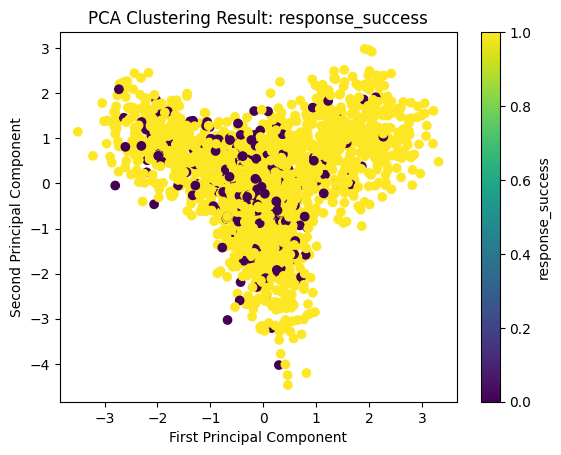

In [20]:
plot_pca(pca_result, train_df, "response_success")

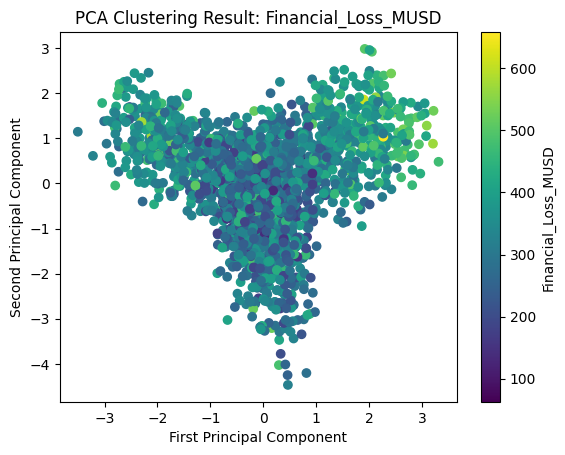

In [21]:
plot_pca(pca_result, train_df, "Financial_Loss_MUSD")

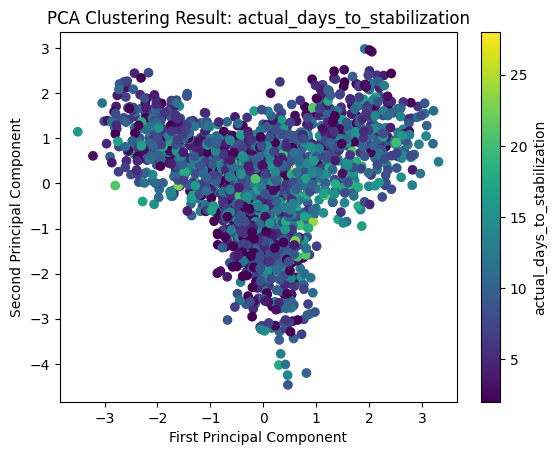

In [22]:
plot_pca(pca_result, train_df, "actual_days_to_stabilization")

In [23]:
cyber_df = train_df[train_df["Threat Type"] == "cyber"].drop(columns=["LCS_COUNT", "Aircraft Count", "Patriot.Batteries"]) # these columns are all 0 for cyber
numeric_df = remove_outcome_and_nonnumeric_colums(cyber_df)
pca_result = pca(numeric_df, dim=2)
pca_result.principal_component_dataframe().head(26)

,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,cyber_defense_teams,ISR_AssetCount,satellite coverage score,JointForceIntegration,EW_Capability,Supply Chain Resilience,PriorEngagements,force_readiness_score,Intel Confidence,ResponseTime_hrs,logistics_delay_hours,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,score,variance_explained
0,-0.064313,-0.276246,-0.465169,-0.182788,-0.072969,-0.289385,0.291881,0.136444,0.226399,0.113295,0.085901,-0.162606,0.177062,0.115881,-0.238998,-0.321512,-0.286402,-0.014684,0.117395,-0.265449,0.084914,1.561539,0.074153
1,-0.016133,-0.127225,-0.050258,0.070525,-0.023337,-0.202648,0.110134,-0.343910,0.220095,-0.100198,0.031477,0.542837,0.021586,0.384328,0.198142,0.287609,-0.127049,0.276034,-0.032207,-0.148114,-0.253832,1.363358,0.064742
2,0.233397,0.335185,0.128578,0.349768,0.134066,0.000066,0.304534,-0.051605,-0.168717,0.079998,0.297967,-0.076706,-0.133175,0.028529,-0.179254,0.053110,-0.305393,0.085553,-0.385013,-0.324223,0.209652,1.325835,0.062960
3,-0.400859,-0.247973,-0.137517,0.476607,-0.070290,0.337067,0.196048,0.006415,0.064561,0.093696,-0.019548,-0.020723,0.216611,-0.330198,0.039225,0.213310,-0.057128,0.316668,0.092060,0.093352,0.192987,1.263126,0.059982
4,0.280367,0.190648,0.131284,0.149982,-0.286491,0.028876,-0.090890,-0.437023,0.189028,0.337986,0.092830,-0.056402,0.402858,-0.206405,-0.027153,-0.124313,-0.168972,-0.194019,0.220947,0.057865,-0.248881,1.222576,0.058057
5,-0.138346,-0.048822,0.022026,0.024067,0.468419,-0.250758,-0.138109,0.241060,0.068735,0.168126,0.498109,0.196851,0.207348,-0.109336,-0.012344,0.293305,-0.059670,-0.343552,0.065523,0.176255,0.002059,1.181512,0.056107
6,0.037835,0.209029,-0.007547,-0.185259,-0.300324,-0.176367,-0.268096,-0.027068,0.361173,-0.328020,-0.044974,0.033284,0.121568,-0.204201,-0.205604,0.359306,-0.046697,0.023718,-0.084684,-0.075864,0.491830,1.093682,0.051936
7,-0.175929,0.118206,0.057937,0.140864,0.166160,-0.075291,0.154135,-0.311218,0.112519,-0.217484,0.158325,-0.134891,-0.246031,0.053186,-0.526969,0.024999,0.358829,0.024711,0.440947,-0.016566,-0.094889,1.080026,0.051287
8,0.049409,0.138279,-0.129009,-0.165304,-0.065878,0.348274,-0.356429,0.167697,-0.035634,0.339701,0.302222,-0.016439,-0.005450,0.216738,0.033947,0.135654,0.168885,0.297012,0.286568,-0.421658,0.046700,1.025861,0.048715
9,-0.512634,0.339400,-0.069007,0.086577,-0.168664,0.190832,0.005171,0.056805,-0.007773,-0.321707,0.082484,-0.123688,0.278786,0.258614,0.128430,-0.034496,-0.010551,-0.368905,-0.150179,-0.215900,-0.219828,0.995893,0.047292


In [24]:
num_interested_principal_components = 4
for i in range(num_interested_principal_components):
    score = pca_result.principal_component_dataframe().at[i, "score"]
    variance_explained = pca_result.principal_component_dataframe().at[i, "variance_explained"]
    print(f"{i+1}th principal component, columns ordered by mangitude (score={score}, variance explained={variance_explained})")
    print(nth_component_columns_ordered_by_magnitude(pca_result, i))

1th principal component, columns ordered by mangitude (score=1.5615392943105848, variance explained=0.07415303336654933)
ThreatEscalationHours       -0.465169
CMD_COORD_SCORE             -0.321512
satellite coverage score     0.291881
ISR_AssetCount              -0.289385
roe_complexity_score        -0.286402
Enemy.Capability.Index      -0.276246
Weather_Severity            -0.265449
logistics_delay_hours       -0.238998
EW_Capability                0.226399
friendlyUnitCount           -0.182788
Intel Confidence             0.177062
force_readiness_score       -0.162606
JointForceIntegration        0.136444
BudgetUtilization_pct        0.117395
ResponseTime_hrs             0.115881
Supply Chain Resilience      0.113295
PriorEngagements             0.085901
Theater Distance KM          0.084914
variance_explained           0.074153
cyber_defense_teams         -0.072969
enemy_unit_count            -0.064313
Operational Budget (MUSD)   -0.014684
Name: 0, dtype: float64
2th principal compo

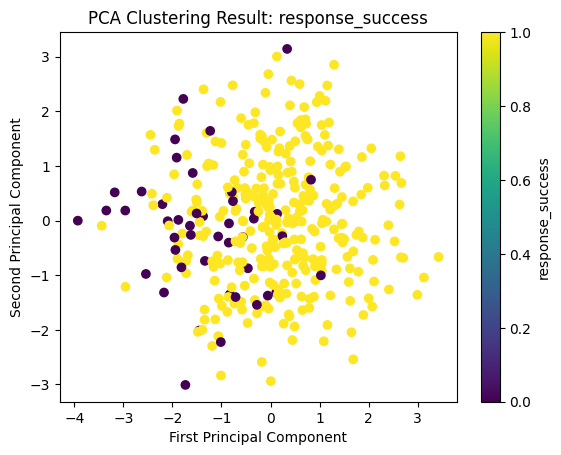

In [25]:
plot_pca(pca_result, cyber_df, "response_success")

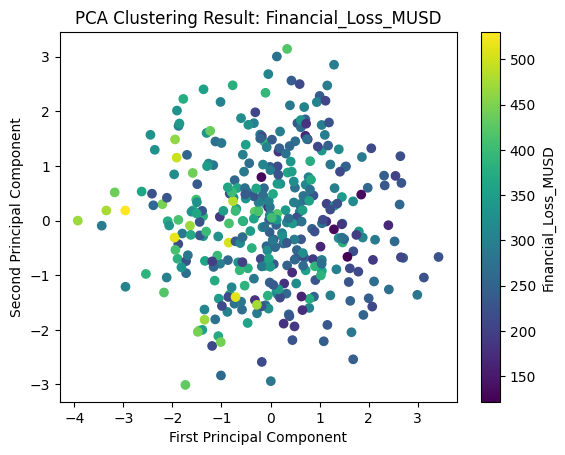

In [26]:
plot_pca(pca_result, cyber_df, "Financial_Loss_MUSD")

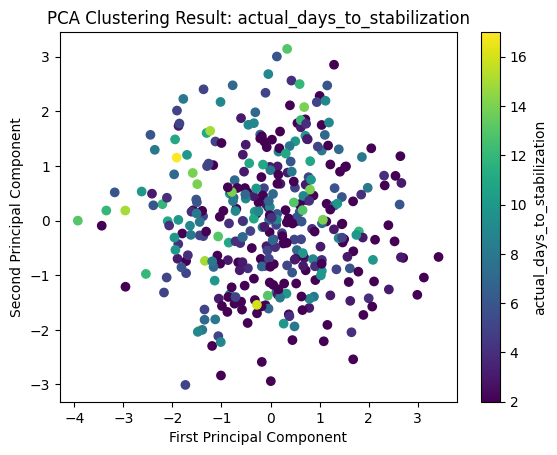

In [27]:
plot_pca(pca_result, cyber_df, "actual_days_to_stabilization")

In [28]:
for threat_type in df["Threat Type"].drop_duplicates():
    print(threat_type, ":", len(df[df["Threat Type"] == threat_type]))

missile : 442
air : 741
cyber : 470
hybrid : 572
naval : 775


In [29]:
hybrid_df = train_df[train_df["Threat Type"] == "hybrid"].drop(columns=[
    "LCS_COUNT",
    "Aircraft Count",
    "cyber_defense_teams",
    "Patriot.Batteries"
]).dropna()
hybrid_pca_result = pca(
    remove_outcome_and_nonnumeric_colums(hybrid_df),
    dim=2
)

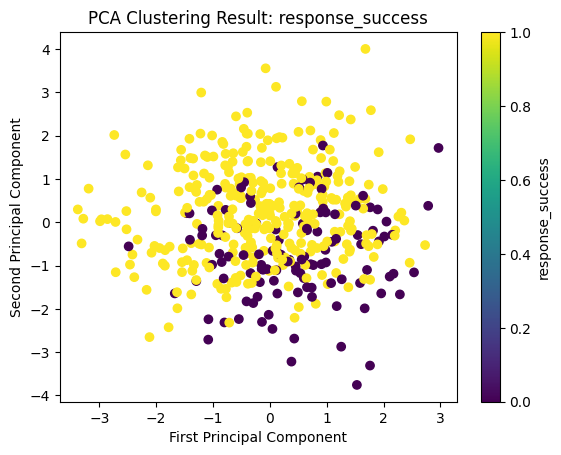

In [30]:
plot_pca(hybrid_pca_result, hybrid_df, "response_success")

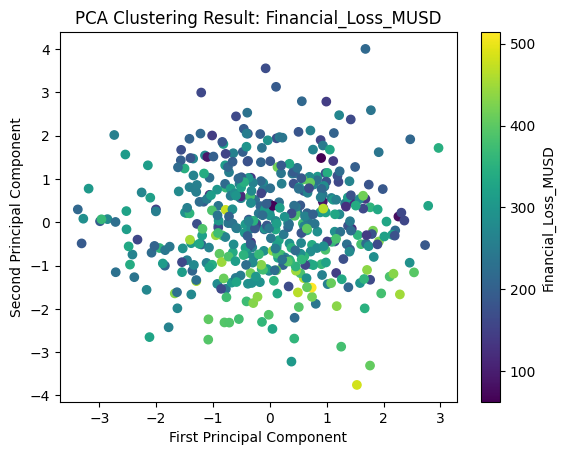

In [31]:
plot_pca(hybrid_pca_result, hybrid_df, "Financial_Loss_MUSD")

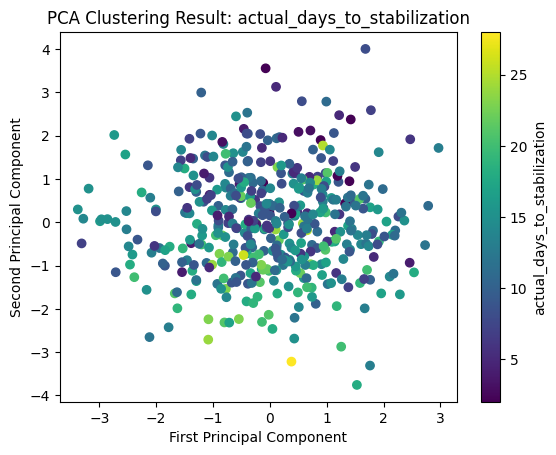

In [32]:
plot_pca(hybrid_pca_result, hybrid_df, "actual_days_to_stabilization")

['winter', 'spring', 'summer', 'fall']
1190    0
2505    1
644     1
2083    2
1360    1
       ..
1371    2
1035    0
1549    3
1256    0
2780    0
Name: Season, Length: 452, dtype: int64


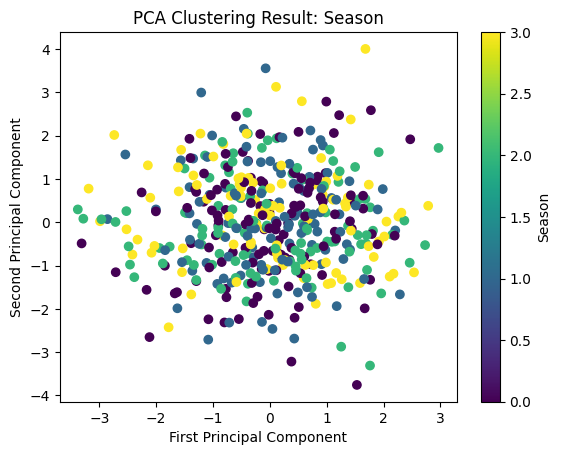

In [33]:
plot_pca(hybrid_pca_result, hybrid_df, "Season")

In [34]:
print_top_n_principal_components(hybrid_pca_result, 11)

1th principal component, columns ordered by mangitude (score=1.402375211170691, variance explained=0.06996363055729883)
satellite coverage score    -0.382514
CMD_COORD_SCORE              0.359468
Theater Distance KM         -0.323882
PriorEngagements            -0.301949
ISR_AssetCount              -0.294223
Intel Confidence            -0.291432
BudgetUtilization_pct        0.281647
friendlyUnitCount            0.252155
ResponseTime_hrs             0.224938
roe_complexity_score         0.209429
logistics_delay_hours       -0.177247
JointForceIntegration        0.161046
Enemy.Capability.Index       0.131359
EW_Capability               -0.128507
Operational Budget (MUSD)   -0.122761
ThreatEscalationHours        0.099903
variance_explained           0.069964
Weather_Severity             0.046792
Supply Chain Resilience      0.025144
force_readiness_score       -0.023120
enemy_unit_count            -0.000115
Name: 0, dtype: float64
2th principal component, columns ordered by mangitude (sco

## Attempt 1: Regression on PCA Components

In [35]:
import math
def nth_val_split(train_df: pd.DataFrame, split_frac: float, n: int):
    if n <= 0:
        raise Exception("Split must be >= 1")
    length = train_df.shape[0]
    start_ind = math.ceil((n - 1) * length * split_frac)
    end_ind = min(
        math.floor(n * length * split_frac),
        length
    )
    val_split = train_df[start_ind:end_ind]
    train_split = train_df.drop(val_split.index)
    return train_split, val_split

In [36]:
hybrid_train_df_subset, hybrid_val_df_subset = nth_val_split(hybrid_df, 0.1, 1)
print(hybrid_train_df_subset.shape, hybrid_val_df_subset.shape)

(407, 25) (45, 25)


In [37]:
from sklearn.linear_model import LogisticRegression

def train_pca_logistic_regression_model(train_df, val_df):
    train_df_nonnumeric = remove_outcome_and_nonnumeric_colums(train_df)
    pca_result = pca(train_df_nonnumeric, 2)
    num_eigenvectors_over_1 = pca_result.num_eigenvectors_with_eigenvalues_over_1()
    X = pca_result.compress(
        train_df_nonnumeric, num_eigenvectors_over_1
    ) 
    y = train_df.dropna().response_success.to_numpy()  
    model = LogisticRegression().fit(X, y)
    compressed_val_set = pca_result.compress(remove_outcome_and_nonnumeric_colums(val_df), num_eigenvectors_over_1)
    return model, model.score(compressed_val_set, val_df.dropna().response_success)


In [38]:
train_pca_logistic_regression_model(hybrid_train_df_subset, hybrid_val_df_subset)[1]

0.8222222222222222

In [39]:
train_pca_logistic_regression_model(*nth_val_split(cyber_df, 0.1, 1))[1]

0.9428571428571428

In [40]:
air_df = train_df[train_df["Threat Type"] == "air"].dropna().drop(columns=["Patriot.Batteries", "cyber_defense_teams", "LCS_COUNT"])
train_pca_logistic_regression_model(*nth_val_split(air_df, 0.1, 1))

(LogisticRegression(), 0.9310344827586207)

In [41]:
missile_df = train_df[train_df["Threat Type"] == "missile"].dropna().drop(columns=["cyber_defense_teams", "LCS_COUNT", "Aircraft Count"])
# remove_outcome_and_nonnumeric_colums(missile_df).sum(axis=0)
train_pca_logistic_regression_model(*nth_val_split(missile_df, 0.1, 1))

(LogisticRegression(), 0.8235294117647058)

In [42]:
naval_df = train_df[train_df["Threat Type"] == "naval"].dropna().drop(columns=["Aircraft Count", "Patriot.Batteries", "cyber_defense_teams"])
train_pca_logistic_regression_model(*nth_val_split(naval_df, 0.1, 1))

(LogisticRegression(), 0.8360655737704918)

In [43]:
hybrid_df_summer = missile_df[missile_df["Season"] == "winter"]
train_pca_logistic_regression_model(*nth_val_split(hybrid_df_summer, 0.1, 1))


(LogisticRegression(), 0.8571428571428571)

## Attempt 2: SVM with RBF kernel

A (very) short summary here is that when we use Support Vector Machines with the RBF kernel, we create a classification boundary that's based on the distance away from points in our train set. This makes our model very explainable - conflicts similar to ones we've seen before will output success or fail with high confidence, and the further we get from known interactions, the lower the confidence will be. 

In [44]:
from sklearn.svm import SVC

train_df_numeric = remove_outcome_and_nonnumeric_colums(hybrid_train_df_subset).to_numpy()
model = SVC(kernel='rbf').fit(train_df_numeric, hybrid_train_df_subset.dropna().response_success)
val_df_numeric = remove_outcome_and_nonnumeric_colums(hybrid_val_df_subset).to_numpy()
score = model.score(val_df_numeric, hybrid_val_df_subset.dropna().response_success)
print(score)

0.6888888888888889


In [47]:
hybrid_df_seasons_one_hot = hybrid_df.copy()

for season in hybrid_df_seasons_one_hot["Season"].drop_duplicates():
    hybrid_df_seasons_one_hot[f"is_{season}"] = hybrid_df_seasons_one_hot["Season"] == season

hybrid_df_seasons_one_hot.head(5)

,Threat Type,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,ISR_AssetCount,satellite coverage score,JointForceIntegration,EW_Capability,Supply Chain Resilience,PriorEngagements,force_readiness_score,Intel Confidence,ResponseTime_hrs,logistics_delay_hours,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,Season,response_success,Financial_Loss_MUSD,actual_days_to_stabilization,is_winter,is_spring,is_summer,is_fall
1190,hybrid,20,3,31,42,15,0.84,10,6.0,0.69,22,49,0.78,45,1,7,3,338,84,8,3756.8,winter,1,273,2.0,True,False,False,False
2505,hybrid,37,3,21,47,0,0.65,4,2.0,0.46,0,100,0.68,22,10,2,1,172,67,9,1202.8,spring,1,176,15.9,False,True,False,False
644,hybrid,7,1,58,20,1,0.91,2,5.0,0.94,21,58,0.59,41,7,6,2,360,87,8,3440.6,spring,1,154,10.8,False,True,False,False
2083,hybrid,35,2,36,5,4,0.80,3,10.0,0.59,17,68,0.85,2,23,3,4,200,95,6,9663.8,summer,1,236,20.9,False,False,True,False
1360,hybrid,49,4,8,42,7,0.30,3,5.0,0.43,9,42,0.48,19,6,7,4,99,65,9,5804.1,spring,0,362,14.5,False,True,False,False


In [54]:
hybrid_df_seasons_one_hot.select_dtypes(exclude="str").corr().loc["actual_days_to_stabilization", "is_summer"]

np.float64(0.05500630054625982)